<a href="https://colab.research.google.com/github/shlok-dhital/6CS012-AI-and-Machine-Learning/blob/main/ShlokDhital_2407091_Workshop7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Activation, GlobalAveragePooling2D)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, UpSampling2D
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()

#data normalization [0,1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

#image reshape
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

In [3]:
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

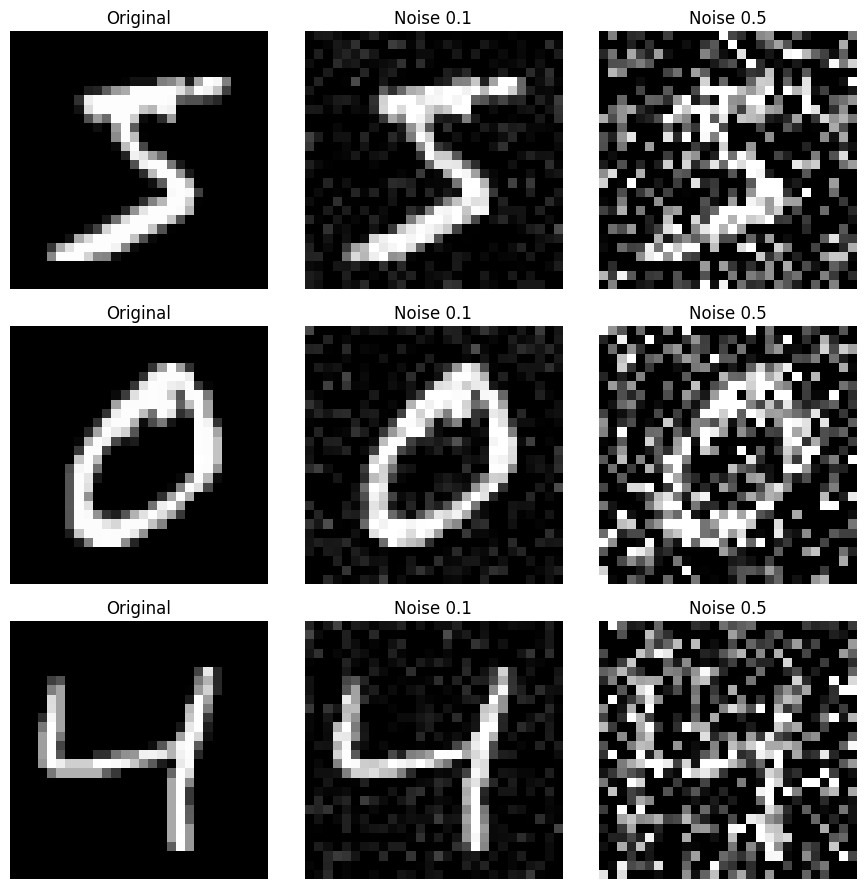

In [4]:
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
  # Original image
  ax = plt.subplot(n, 3, i * 3 + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title("Original")
  plt.axis('off')
  # Low noise image
  ax = plt.subplot(n, 3, i * 3 + 2)
  plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.1")
  plt.axis('off')
  # High noise image
  ax = plt.subplot(n, 3, i * 3 + 3)
  plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.5")
  plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
def build_encoder(input_shape=(28, 28, 1)):
  """
  Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
  """
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

In [6]:
def build_decoder(encoded_input):
  """
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
  encoded_input (Keras Tensor): The output from the encoder.
  Returns:
  decoded (Keras Tensor): The reconstructed output after upsampling and
  convolution.
  """
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

In [7]:
def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

In [8]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train with noisy input and clean target
history = autoencoder.fit(
  x_train_noisy_high, x_train,
  epochs=10,
  batch_size=128,
  shuffle=True,
  validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 418ms/step - loss: 0.1499 - val_loss: 0.1112
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 428ms/step - loss: 0.1084 - val_loss: 0.1051
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 183s 389ms/step - loss: 0.1034 - val_loss: 0.1017
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 181s 386ms/step - loss: 0.1010 - val_loss: 0.0997
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 383ms/step - loss: 0.0994 - val_loss: 0.0981
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 393ms/step - loss: 0.0983 - val_loss: 0.0968
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 385ms/step - loss: 0.0974 - val_loss: 0.0962
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 183s 390ms/step - loss: 0.0966 - val_loss: 0.0957
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 182s 387ms/step - loss: 0.0960 - val_loss: 0.0951
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 380ms/step - loss: 0.0956 - val_loss: 0.0947


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


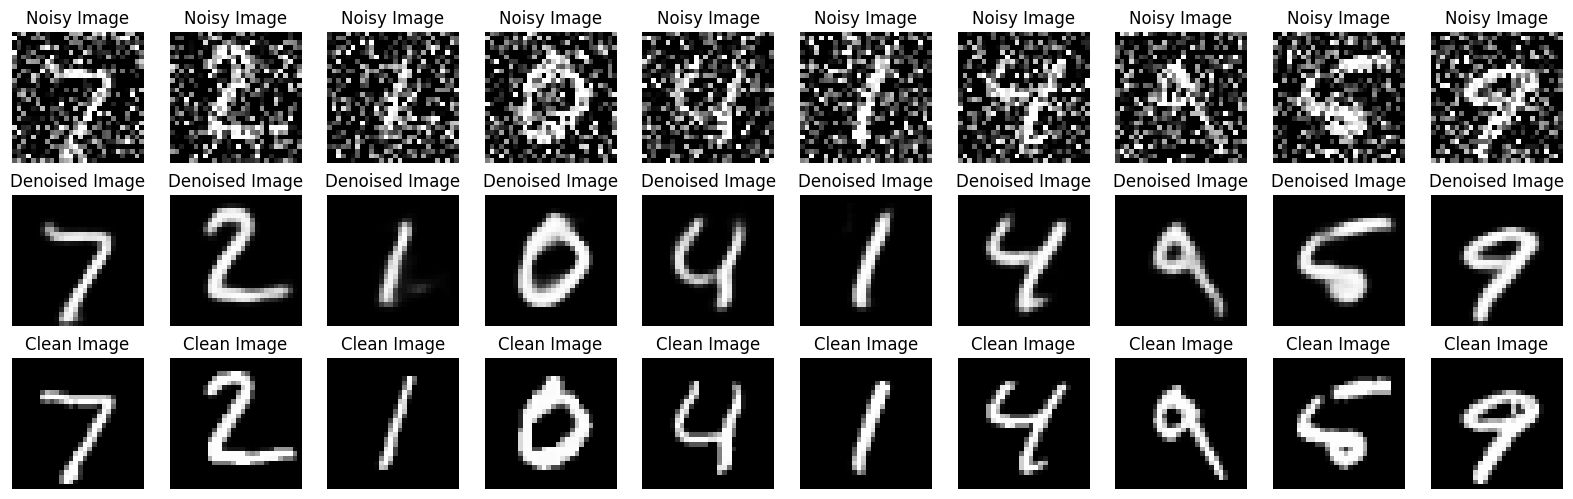

In [10]:
# Evaluate the Autoencoder
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)
# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):
    # Plot noisy images
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Image")
    plt.axis('off')
    # Plot denoised images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised Image")
    plt.axis('off')
    # Plot clean images
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
    plt.title("Clean Image")
    plt.axis('off')
  plt.show()
# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

#Build a Denoising Convolutional Autoencoder

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
data_path = '/content/drive/MyDrive/AI - ShlokDhital/DevanagariHandwrittenDigitDatasetExtracted/'

train_path = os.path.join(data_path, 'Train')
test_path = os.path.join(data_path, 'Test')

def load_images(folder_path):
    images = []

    for digit in os.listdir(folder_path):
        digit_path = os.path.join(folder_path, digit)

        if os.path.isdir(digit_path):
            for file in os.listdir(digit_path):
                img_path = os.path.join(digit_path, file)

                try:
                    img = Image.open(img_path).convert('L')
                    img = img.resize((28, 28))
                    img = np.array(img)

                    images.append(img)
                except:
                    continue

    return np.array(images)

In [14]:
x_train = load_images(train_path)
x_test = load_images(test_path)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (17023, 28, 28)
Test shape: (3000, 28, 28)


In [15]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [16]:
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)

x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

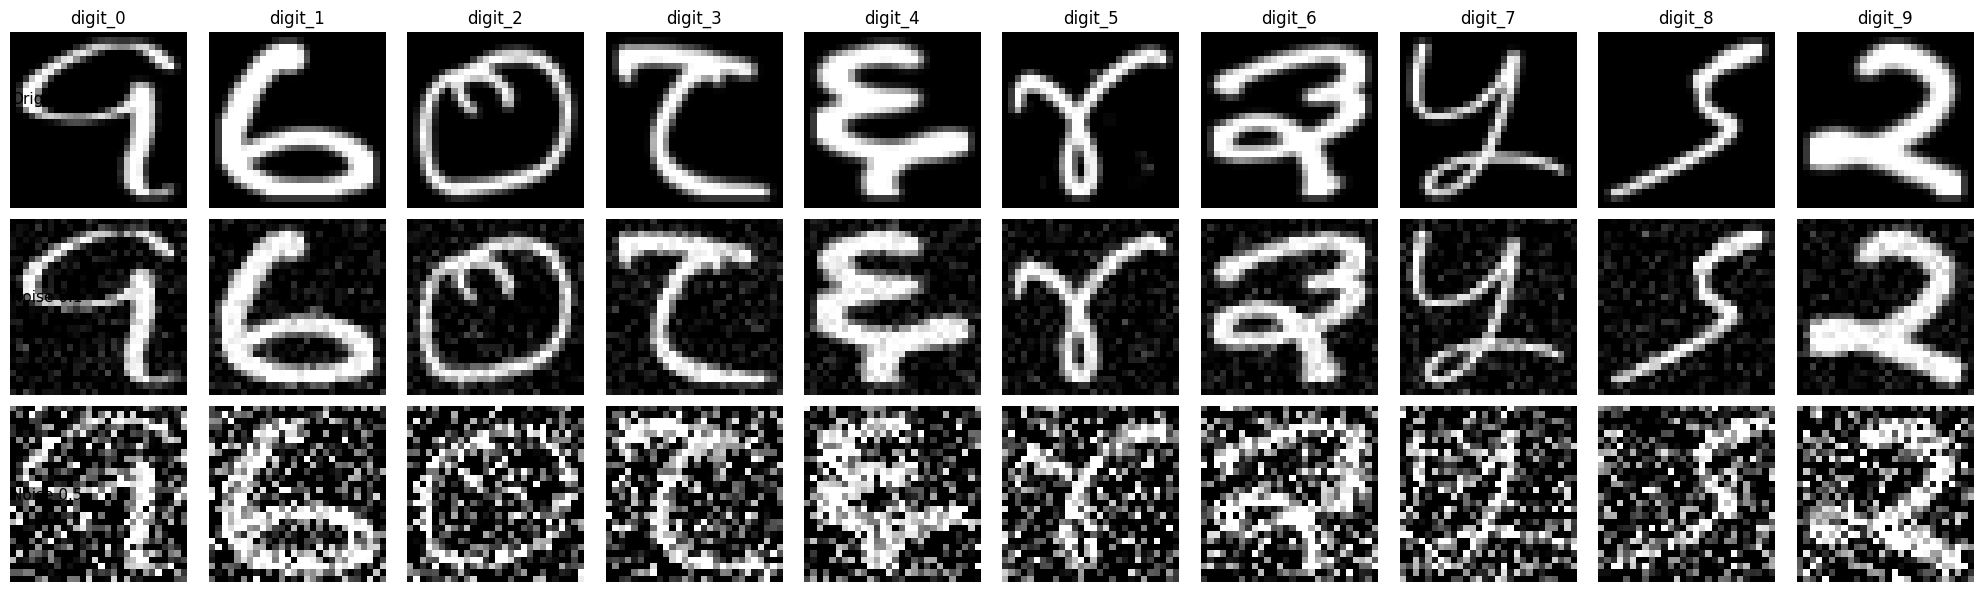

In [17]:
digit_folders = sorted(os.listdir(train_path))

images_per_digit = {}
for digit in digit_folders:
    digit_path = os.path.join(train_path, digit)
    if os.path.isdir(digit_path):
        images_per_digit[digit] = len([
            f for f in os.listdir(digit_path)
            if os.path.isfile(os.path.join(digit_path, f))
        ])

digit_indices = []
cumulative = 0
for digit in digit_folders:
    if digit in images_per_digit:
        digit_indices.append((digit, cumulative))
        cumulative += images_per_digit[digit]

n_digits = len(digit_indices)
plt.figure(figsize=(20, 6))

for col, (label, idx) in enumerate(digit_indices):
    plt.subplot(3, n_digits, col + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"{label}")
    plt.axis('off')

    plt.subplot(3, n_digits, col + 1 + n_digits)
    plt.imshow(x_train_noisy_low[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')

    plt.subplot(3, n_digits, col + 1 + 2 * n_digits)
    plt.imshow(x_train_noisy_high[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')

# Row labels on the left
plt.gcf().text(0.01, 0.83, "Original", va='center', fontsize=11)
plt.gcf().text(0.01, 0.50, "Noise 0.1", va='center', fontsize=11)
plt.gcf().text(0.01, 0.17, "Noise 0.5", va='center', fontsize=11)

plt.tight_layout()
plt.show()

In [18]:
def build_encoder(input_shape=(28,28,1)):
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same', name="encoded")(x)

    return input_img, encoded

In [19]:
def build_decoder(encoded_input):
    x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2,2))(x)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)

    decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same', name="decoded")(x)

    return decoded

In [20]:
def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output)
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 67s 469ms/step - loss: 0.2999 - val_loss: 0.2188
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 74s 415ms/step - loss: 0.2081 - val_loss: 0.2007
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 80s 402ms/step - loss: 0.1992 - val_loss: 0.1958
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 56s 420ms/step - loss: 0.1958 - val_loss: 0.1956
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 80s 404ms/step - loss: 0.1928 - val_loss: 0.1922
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 56s 419ms/step - loss: 0.1906 - val_loss: 0.1896
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 54s 408ms/step - loss: 0.1891 - val_loss: 0.1877
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 56s 415ms/step - loss: 0.1875 - val_loss: 0.1867
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 57s 431ms/step - loss: 0.1867 - val_loss: 0.1864
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 78s 402ms/step - loss: 0.1857 - val_loss: 0.1849


In [22]:
denoised_images = autoencoder.predict(x_test_noisy_high)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


In [23]:
def plot_images(noisy, denoised, clean, n=10):
    plt.figure(figsize=(20,6))

    for i in range(n):
        plt.subplot(3,n,i+1)
        plt.imshow(noisy[i].reshape(28,28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        plt.subplot(3,n,i+1+n)
        plt.imshow(denoised[i].reshape(28,28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        plt.subplot(3,n,i+1+2*n)
        plt.imshow(clean[i].reshape(28,28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

    plt.show()

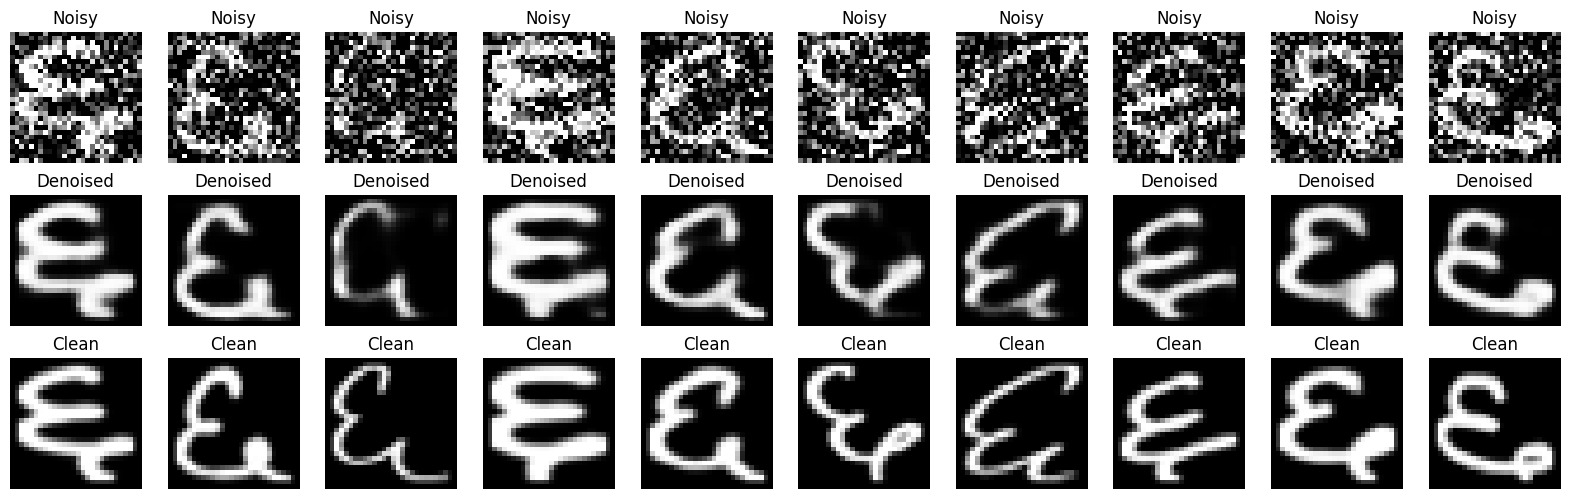

In [24]:
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

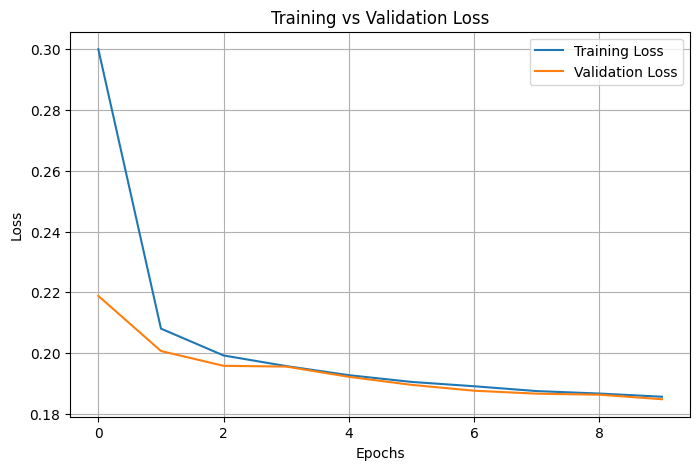

In [25]:
plt.figure(figsize=(8,5))

# Training loss
plt.plot(history.history['loss'], label='Training Loss')

# Validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()